# Setup

In [11]:
# Import required libraries
# Avoid KMeans memory leak issue on Windows with Intel MKL
import os
os.environ['OMP_NUM_THREADS'] = '1'
import warnings
warnings.filterwarnings('ignore', message='KMeans is known to have a memory leak')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
np.random.seed(42)
print("Libraries loaded successfully!")

Libraries loaded successfully!


## The Gaussian (RBF) Activation Function

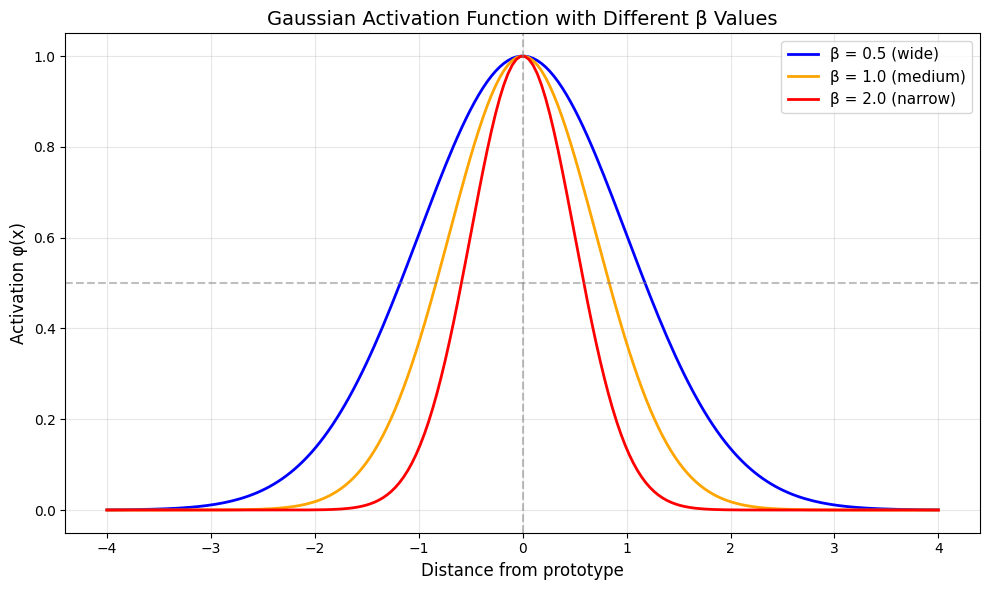


Key observation:
- When input equals prototype (distance = 0), activation = 1.0
- As input moves away from prototype, activation falls towards 0
- β controls how quickly the activation falls off


In [ ]:
# Visualise the Gaussian function with different β values
def gaussian(x, centre, beta):
    """
    Compute Gaussian activation.

    Parameters:
    x: Input value(s)
    centre: The prototype/centre of the Gaussian
    beta: Width parameter (larger = narrower curve)

    Returns:
    Activation value(s) in range [0, 1]
    """
    distance_squared = (x - centre) ** 2
    
    ## TODO: use the numpy's "exp" function to return the gaussian activation
    ## function value (see equation in the markdown cell above)
    return np.exp(-beta * distance_squared)
    

# Create x values
## TODO: use the numpy's "linspace" function to create 200 evenly
## spaced values for x over the interval [-4,4].
x = np.linspace(-4, 4, 200)

centre = 0 # Prototype at origin

# Plot Gaussians with different β values
plt.figure(figsize=(10, 6))

for beta, color, label in [(0.5, 'blue', 'β = 0.5 (wide)'),
                            (1.0, 'orange', 'β = 1.0 (medium)'),
                            (2.0, 'red', 'β = 2.0 (narrow)')]:
    y = gaussian(x, centre, beta)
    plt.plot(x, y, color=color, linewidth=2, label=label)


plt.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='grey', linestyle='--', alpha=0.5)
plt.xlabel('Distance from prototype', fontsize=12)
plt.ylabel('Activation φ(x)', fontsize=12)
plt.title('Gaussian Activation Function with Different β Values', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('gaussian_activation.png', dpi=150)
plt.show()
print("\nKey observation:")
print("- When input equals prototype (distance = 0), activation = 1.0")
print("- As input moves away from prototype, activation falls towards 0")
print("- β controls how quickly the activation falls off")